# Example of likelihood calculation for BAO

In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.jax_cosmology import JAXBackground

# cloelike imports
from cloelike.EuclidLikelihood_BAO import EuclidLikelihood_BAO

### Download the data from Zenodo

In [3]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'bao_z1.00.fits': 'https://zenodo.org/records/15698427/files/bao_z1.00.fits',
        'bao_z1.20.fits': 'https://zenodo.org/records/15698427/files/bao_z1.20.fits',
        'bao_z1.40.fits': 'https://zenodo.org/records/15698427/files/bao_z1.40.fits',
        'bao_z1.65.fits': 'https://zenodo.org/records/15698427/files/bao_z1.65.fits',}
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

bao_z1.00.fits downloaded successfully
bao_z1.20.fits downloaded successfully
bao_z1.40.fits downloaded successfully
bao_z1.65.fits downloaded successfully


Load the datafiles and construct a `data{'BAO'}` dictionary.
(Later change this to download the datafiles from Zenodo)

In [10]:
# Read files and construct a data dictionary

filenames = ['./bao_z1.00.fits', './bao_z1.20.fits', './bao_z1.40.fits', './bao_z1.65.fits']

data = {'BAO': {}}

for i in range(len(filenames)):
    with fits.open(filenames[i]) as hdul:
        # --- Primary Header ---
        hdr = hdul[0].header
        zmean = hdr['ZMEAN']
        param_names = hdr['PARAMS'].split(',')

        # Read fiducial cosmology
        fiducial_cosmo = {key_cloe: hdr[key]
        for key_cloe, key in zip(['H0', 'Omega_m0', 'Omega_b0'],['H0', 'OMEGA_M', 'OMEGA_B'])}
        fiducial_cosmo['Omega_cdm0'] = fiducial_cosmo.pop('Omega_m0') - fiducial_cosmo['Omega_b0']
        # This is needed by Background to compute fiducial quantities. They are set to default
        # values as they are not specified in the fiducial cosmology of the data
        for key,val in zip(['Omega_k0', 'As', 'ns', 'mnu','w0','wa','gamma_MG', 'N_mnu'],
                           [0., 2.1e-9, 0.96, 0., -1., 0., 0.545, 0]):
            fiducial_cosmo.setdefault(key, val)

        # --- Measurements Table ---
        table = hdul['MEASUREMENTS'].data
        values = {row['PARAM']: row['VALUE'] for row in table}

        # --- Covariance Matrix ---
        cov = hdul['COVMAT'].data
        data['BAO'][zmean] = {'params': param_names,
                              'fiducial_cosmology': fiducial_cosmo,
                              'data': values,
                              'covariance': cov}


Visualise the structure of the data dictionary

In [11]:
data

{'BAO': {1.0: {'params': ['alpha_par', 'alpha_perp'],
   'fiducial_cosmology': {'H0': 67.0,
    'Omega_b0': 0.049,
    'Omega_cdm0': 0.27,
    'Omega_k0': 0.0,
    'As': 2.1e-09,
    'ns': 0.96,
    'mnu': 0.0,
    'w0': -1.0,
    'wa': 0.0,
    'gamma_MG': 0.545,
    'N_mnu': 0},
   'data': {'alpha_par': np.float64(1.0), 'alpha_perp': np.float64(1.0)},
   'covariance': array([[ 0.00060068, -0.0001272 ],
          [-0.0001272 ,  0.00016146]], dtype='>f8')},
  1.2: {'params': ['alpha_par', 'alpha_perp'],
   'fiducial_cosmology': {'H0': 67.0,
    'Omega_b0': 0.049,
    'Omega_cdm0': 0.27,
    'Omega_k0': 0.0,
    'As': 2.1e-09,
    'ns': 0.96,
    'mnu': 0.0,
    'w0': -1.0,
    'wa': 0.0,
    'gamma_MG': 0.545,
    'N_mnu': 0},
   'data': {'alpha_par': np.float64(1.0), 'alpha_perp': np.float64(1.0)},
   'covariance': array([[ 0.00053732, -0.00011991],
          [-0.00011991,  0.0001598 ]], dtype='>f8')},
  1.4: {'params': ['alpha_par', 'alpha_perp'],
   'fiducial_cosmology': {'H0': 67.0

## Create an `EuclidLikelihood_BAO` object

This needs in input a data dictionary, and the Background type; here we use the `CAMBBackground` object:

In [12]:
like_bao = EuclidLikelihood_BAO(data=data, Background=CAMBBackground)
vars(like_bao)

{'data': {'BAO': {1.0: {'params': ['alpha_par', 'alpha_perp'],
    'fiducial_cosmology': {'H0': 67.0,
     'Omega_b0': 0.049,
     'Omega_cdm0': 0.27,
     'Omega_k0': 0.0,
     'As': 2.1e-09,
     'ns': 0.96,
     'mnu': 0.0,
     'w0': -1.0,
     'wa': 0.0,
     'gamma_MG': 0.545,
     'N_mnu': 0},
    'data': {'alpha_par': np.float64(1.0), 'alpha_perp': np.float64(1.0)},
    'covariance': array([[ 0.00060068, -0.0001272 ],
           [-0.0001272 ,  0.00016146]], dtype='>f8')},
   1.2: {'params': ['alpha_par', 'alpha_perp'],
    'fiducial_cosmology': {'H0': 67.0,
     'Omega_b0': 0.049,
     'Omega_cdm0': 0.27,
     'Omega_k0': 0.0,
     'As': 2.1e-09,
     'ns': 0.96,
     'mnu': 0.0,
     'w0': -1.0,
     'wa': 0.0,
     'gamma_MG': 0.545,
     'N_mnu': 0},
    'data': {'alpha_par': np.float64(1.0), 'alpha_perp': np.float64(1.0)},
    'covariance': array([[ 0.00053732, -0.00011991],
           [-0.00011991,  0.0001598 ]], dtype='>f8')},
   1.4: {'params': ['alpha_par', 'alpha_perp'

## Timing the initialisation of the `EuclidLikelihood_BAO` object and the likelihood evaluation
These mainly depend on the type of `Background` used

In [17]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545, 'N_mnu': 0,
    }

print("⏱️ Timing initialisation with CAMB:")
%timeit like_bao = EuclidLikelihood_BAO(data=data, Background=CAMBBackground)

⏱️ Timing initialisation with CAMB:
8.15 ms ± 440 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [18]:
like_bao = EuclidLikelihood_BAO(data=data, Background=CAMBBackground)

print("⏱️ Timing log-likelihood evaluation:")

%timeit loglike_val = like_bao.loglike(parameters)

loglike_val = like_bao.loglike(parameters)
print(f"Log-likelihood: {loglike_val}")
print(f"-2 * log-likelihood: {-2 * loglike_val}")

⏱️ Timing log-likelihood evaluation:
8.07 ms ± 170 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Log-likelihood: -0.0
-2 * log-likelihood: 0.0


Compute the $\chi^2$ for different values of the parameters:

In [19]:
from IPython.display import display, Math

def print_chi2(parameters, like, description):
    chi2 = -2 * like.loglike(parameters)
    print(f"🔧 {description}")
    display(Math(r"\chi^2 = {:.3f}".format(chi2)))
    print("-" * 40)

# Starting from original parameters dict
params = parameters.copy()  # to avoid modifying original dict if needed

# 1. Change H0 to 70.0
params['H0'] = 68.0
print_chi2(params, like_bao, "Changed H0 to 70.0")

# 2. Change w0 to -1.2
params['w0'] = -1.2
print_chi2(params, like_bao, "Set w0 to -1.2")

# 4. Change Omega_k0 to 0.2
params['Omega_k0'] = 0.2
print_chi2(params, like_bao, "Set Omega_k0 to 0.2")

🔧 Changed H0 to 70.0


<IPython.core.display.Math object>

----------------------------------------
🔧 Set w0 to -1.2


<IPython.core.display.Math object>

----------------------------------------
🔧 Set Omega_k0 to 0.2


<IPython.core.display.Math object>

----------------------------------------


Computing likelihood: 100%|██████████| 200/200 [00:01<00:00, 116.51it/s]


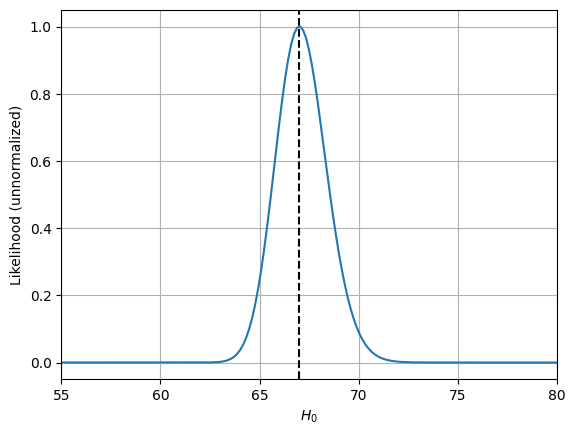

In [20]:
from tqdm import tqdm
like = EuclidLikelihood_BAO(data=data, Background=CAMBBackground)

H0_vals = np.linspace(50, 80, 200)
loglike_vals = []

for val in tqdm(H0_vals, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    parameters['H0'] = val
    loglike_vals.append(like.loglike(parameters))

loglike_vals = np.array(loglike_vals)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals = np.exp(loglike_vals - np.max(loglike_vals))  # subtract max for numerical stability

plt.plot(H0_vals, likelihood_vals)
plt.axvline(67, color='k', ls='--')
plt.xlim([55, 80])
plt.grid(True)
plt.xlabel(r'$H_0$')
plt.ylabel('Likelihood (unnormalized)')
plt.show()